In [8]:
# Task 1 RESTAURANT REVIEWS
# Analyze the text reviews to identify the most common positive and negative keywords

import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

#load the dataset
df = pd.read_csv(r"C:\Users\Acer\Downloads\Dataset.csv")
df.shape

(9551, 21)

In [7]:
text_column = 'Cuisines'

#define rating sentiment
pos_ratings = ['Excellent','Very Good','Good']
neg_ratings = ['Poor','Average']

# clean and tokenize
def tokenize(text):
    return re.sub(r'[^a-z\s]','',str(text).lower()).split()

# collect words
pos_words,neg_words = [],[]
for _,row in df.iterrows():
    tokens = tokenize(row[text_column])
    if row['Rating text'] in pos_ratings:
        pos_words.extend(tokens)
    elif row['Rating text'] in neg_ratings:
        neg_words.extend(tokens)
print('Top positive keywords:',Counter(pos_words).most_common(10))
print('Top negative keywords:',Counter(neg_words).most_common(10))

Top positive keywords: [('indian', 1298), ('north', 1080), ('food', 827), ('chinese', 772), ('italian', 550), ('fast', 514), ('continental', 504), ('cafe', 433), ('desserts', 319), ('american', 301)]
Top negative keywords: [('indian', 2286), ('north', 1942), ('food', 1423), ('chinese', 1412), ('fast', 1050), ('mughlai', 524), ('south', 339), ('bakery', 315), ('street', 255), ('desserts', 224)]


In [9]:
# calculate the average length of reviews and explore if there is a relationship between review length and ratings

df['review_text'] = df['Cuisines']
# compute review length
df['review_length'] = df['review_text'].astype(str).apply(lambda x:len(x.split()))

# group by rating text & calculate average review length
avg_lengths = df.groupby('Rating text')['review_length'].mean().sort_values(ascending = False)
print('Average review length by rating:',avg_lengths)


Average review length by rating: Rating text
Poor         3.392473
Good         3.110952
Average      3.017394
Very Good    2.951807
Excellent    2.654485
Not rated    2.439479
Name: review_length, dtype: float64


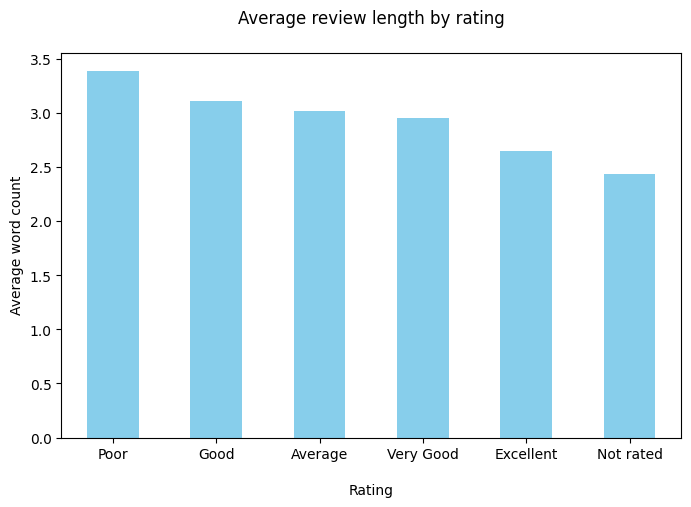

In [20]:
plt.figure(figsize = (8,5))
avg_lengths.plot(kind='bar',color='skyblue')
plt.title('Average review length by rating\n')
plt.xlabel('\nRating')
plt.ylabel('Average word count')
plt.xticks(rotation = 0)
plt.show()